# DDM Feasibility: Inter-Treebank Variance at Fixed Sentence Lengths

This notebook checks whether **Dependency Displacement Measure (DDM)** values vary meaningfully across treebanks when computed at fixed sentence lengths, and whether **length-standardized DDM** rankings differ from naive (length-pooled) rankings.

**What it does:**
1. Loads pre-computed treebank DDM results (naive vs standardized)
2. Analyzes inter-treebank variance of DDM(n) at target lengths
3. Compares naive vs standardized DDM rankings via Spearman correlation
4. Renders a feasibility verdict (PASS/MARGINAL/FAIL)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used are pre-installed on Colab; install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-3bc3de-sentence-length-standardization-reveals-/main/experiment_iter2_ddm_feasibility/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'][0]['examples'])} treebank results")
print(f"Feasibility verdict: {data['metadata']['feasibility_verdict']}")

Loaded 10 treebank results
Feasibility verdict: PASS


## Configuration

Target sentence lengths and thresholds for the feasibility check.

In [5]:
TARGET_LENGTHS = [5, 10, 15, 20, 25, 30]
BIN_HALF_WIDTH = 2
MIN_SENTENCES = 10

## Extract Per-Treebank DDM Results

Parse the output JSON for each treebank to get naive DDM, standardized DDM, DDM at target lengths, and rank changes.

In [6]:
examples = data["datasets"][0]["examples"]
metadata = data["metadata"]

treebanks = []
naive_ddms = []
std_ddms = []
rank_changes = []
ddm_at_lengths = {str(n): [] for n in TARGET_LENGTHS}

for ex in examples:
    tb = ex["metadata_treebank_id"]
    out = json.loads(ex["output"])
    treebanks.append(tb)
    naive_ddms.append(out["naive_ddm"])
    std_ddms.append(out["standardized_ddm"])
    rank_changes.append(out["rank_change"])
    for n in TARGET_LENGTHS:
        ddm_at_lengths[str(n)].append(out["ddm_at_target_lengths"].get(str(n), float("nan")))

print(f"{len(treebanks)} treebanks: {treebanks}")

10 treebanks: ['ar_padt', 'cs_cac', 'de_gsd', 'en_ewt', 'es_ancora', 'eu_bdt', 'fi_tdt', 'fr_gsd', 'he_htb', 'hi_hdtb']


## Inter-Treebank Variance Analysis

Examine how DDM(n) varies across treebanks at each target sentence length. Higher CV (coefficient of variation) means more meaningful inter-treebank differences.

In [7]:
variance_stats = metadata["variance_stats_by_n"]
print(f"{'n':>3}  {'Mean DDM':>10}  {'Std':>8}  {'CV':>8}  {'Range':>8}  {'#TB':>4}")
print("-" * 50)
for n in TARGET_LENGTHS:
    s = variance_stats[str(n)]
    print(f"{n:3d}  {s['mean']:10.4f}  {s['std']:8.4f}  {s['cv']:8.4f}  {s['range']:8.4f}  {s['num_treebanks']:4d}")

cv_values = [variance_stats[str(n)]["cv"] for n in TARGET_LENGTHS]
print(f"\nMean CV across lengths: {np.mean(cv_values):.4f}")

  n    Mean DDM       Std        CV     Range   #TB
--------------------------------------------------
  5      0.1771    0.0658    0.3713    0.2630    20
 10      0.3657    0.0494    0.1350    0.1832    20
 15      0.4795    0.0424    0.0885    0.1942    20
 20      0.5525    0.0336    0.0609    0.1510    20
 25      0.6094    0.0323    0.0530    0.1533    20
 30      0.6484    0.0323    0.0498    0.1473    20

Mean CV across lengths: 0.1264


## Naive vs Standardized DDM Rankings

Compare rankings: Spearman correlation and per-treebank rank changes.

In [8]:
rho, p_val = stats.spearmanr(naive_ddms, std_ddms)
print(f"Spearman rho (naive vs standardized): {rho:.4f} (p={p_val:.4e})")
print(f"Max rank change: {metadata['max_rank_change']}")
print(f"Mean pairwise KL divergence of P(n): {metadata['mean_pairwise_kl']:.4f}")
print(f"\nFeasibility verdict: {metadata['feasibility_verdict']}")
print(f"Reason: {metadata['feasibility_reason']}")

print(f"\n{'Treebank':<15} {'Naive DDM':>10} {'Std DDM':>10} {'Rank Δ':>8}")
print("-" * 47)
for tb, nd, sd, rc in zip(treebanks, naive_ddms, std_ddms, rank_changes):
    print(f"{tb:<15} {nd:10.4f} {sd:10.4f} {rc:+8d}")

Spearman rho (naive vs standardized): 0.7697 (p=9.2220e-03)
Max rank change: 14
Mean pairwise KL divergence of P(n): 0.8624

Feasibility verdict: PASS
Reason: Meaningful DDM(n) variation across treebanks (mean CV=0.1264), diverse P(n) distributions (mean KL=0.8624), standardization changes rankings (rho=0.5549, max rank change=14)

Treebank         Naive DDM    Std DDM   Rank Δ
-----------------------------------------------
ar_padt             0.7296     0.5160       -2
cs_cac              0.5738     0.4705       -4
de_gsd              0.4938     0.4293       -4
en_ewt              0.5199     0.4585       -4
es_ancora           0.6940     0.4809       -9
eu_bdt              0.4613     0.4584       -1
fi_tdt              0.4541     0.4588       +2
fr_gsd              0.6439     0.5069       +2
he_htb              0.6464     0.4855       -6
hi_hdtb             0.5602     0.4881       +2


## Visualization

**Left:** DDM(n) curves per treebank across sentence lengths — shows how DDM increases with length.
**Right:** Naive vs Standardized DDM scatter — points far from diagonal indicate ranking changes from standardization.

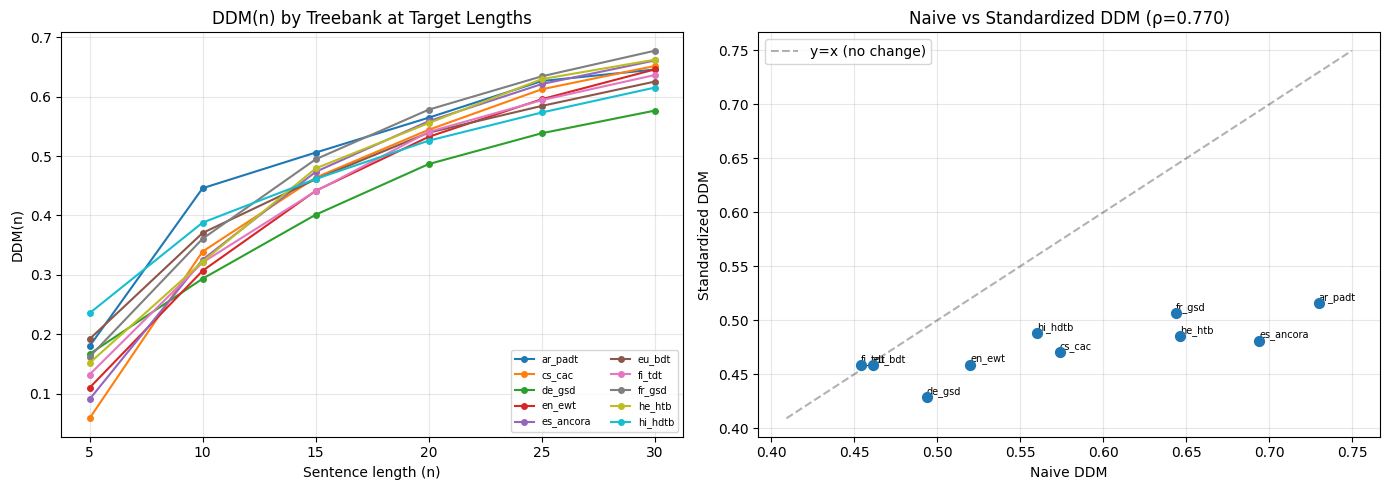

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: DDM(n) curves per treebank
for i, tb in enumerate(treebanks):
    vals = [ddm_at_lengths[str(n)][i] for n in TARGET_LENGTHS]
    ax1.plot(TARGET_LENGTHS, vals, 'o-', label=tb, markersize=4)
ax1.set_xlabel("Sentence length (n)")
ax1.set_ylabel("DDM(n)")
ax1.set_title("DDM(n) by Treebank at Target Lengths")
ax1.legend(fontsize=7, ncol=2, loc="lower right")
ax1.grid(True, alpha=0.3)

# Right: Naive vs Standardized DDM
ax2.scatter(naive_ddms, std_ddms, s=50, zorder=5)
for tb, nd, sd in zip(treebanks, naive_ddms, std_ddms):
    ax2.annotate(tb, (nd, sd), fontsize=7, ha="left", va="bottom")
lims = [min(min(naive_ddms), min(std_ddms)) - 0.02, max(max(naive_ddms), max(std_ddms)) + 0.02]
ax2.plot(lims, lims, 'k--', alpha=0.3, label="y=x (no change)")
ax2.set_xlabel("Naive DDM")
ax2.set_ylabel("Standardized DDM")
ax2.set_title(f"Naive vs Standardized DDM (ρ={rho:.3f})")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()